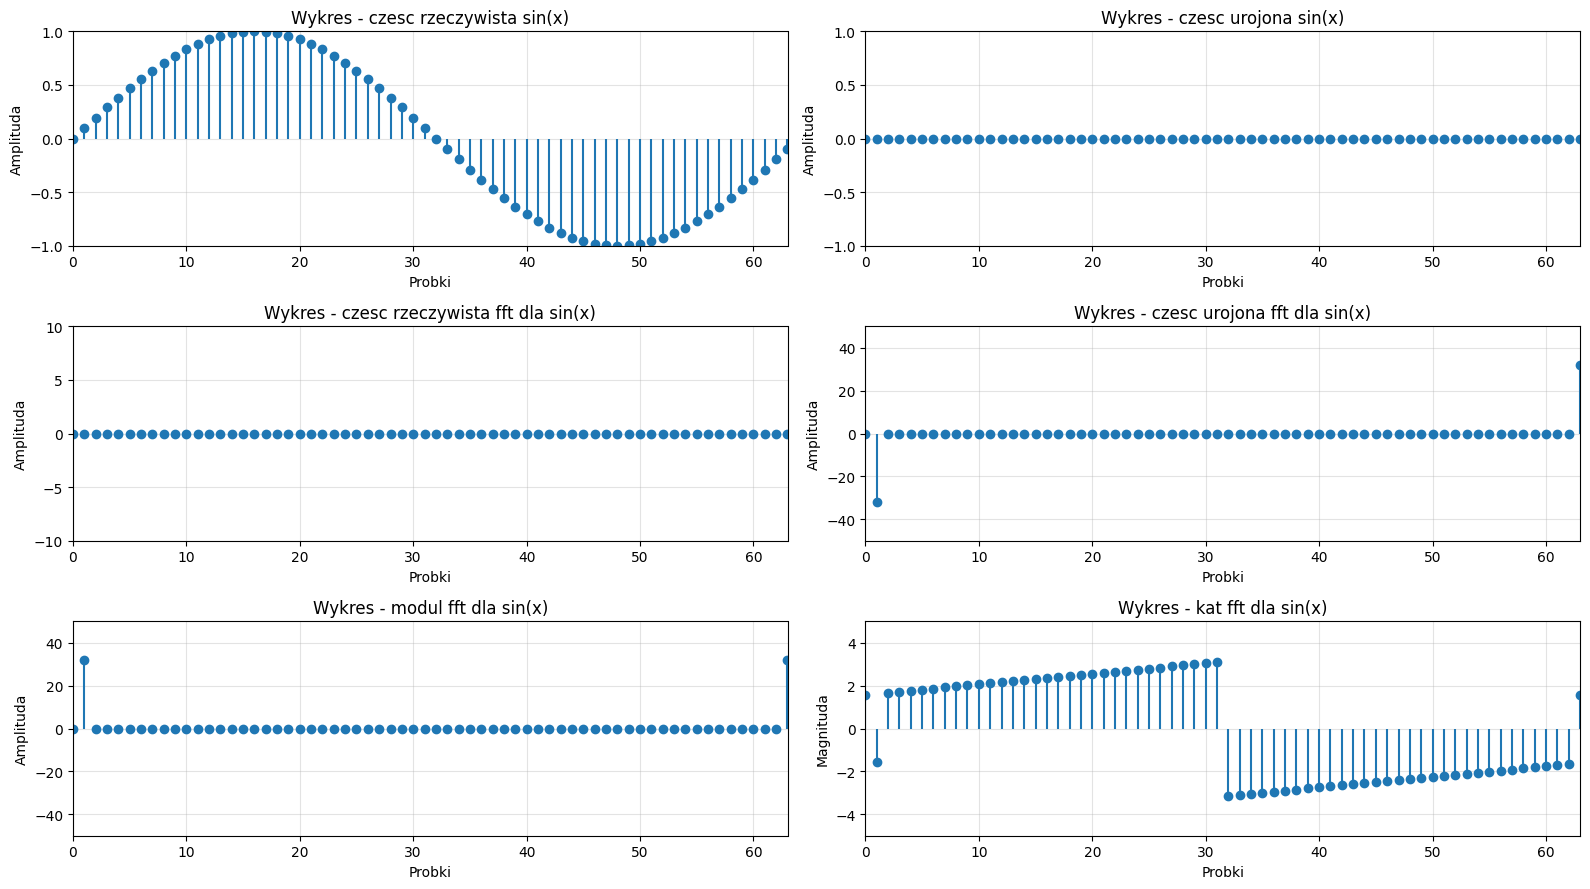

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry probkowania i czestotliwosci sygnalu testowego
N = 64
fs = 64  # Hz
f0 = 1   # Hz
n = np.arange(N)

# Dyskretny sinus, na ktorym wykonujemy dalsza analize FFT
x = np.sin(2 * np.pi * f0 * n / fs)

# FFT bez normalizacji, zeby amplitudy byly jak na podgladzie (piki ok. 32 dla N=64)
X = np.fft.fft(x)
k = np.arange(N)

plt.figure(figsize=(16, 9))

# 1) Czesc rzeczywista sygnalu w czasie
plt.subplot(3, 2, 1)
plt.stem(n, np.real(x), basefmt=' ')
plt.title("Wykres - czesc rzeczywista sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-1, 1)
plt.grid(True, alpha=0.35)

# 2) Czesc urojona sygnalu w czasie
plt.subplot(3, 2, 2)
plt.stem(n, np.imag(x), basefmt=' ')
plt.title("Wykres - czesc urojona sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-1, 1)
plt.grid(True, alpha=0.35)

# 3) Czesc rzeczywista FFT
plt.subplot(3, 2, 3)
plt.stem(k, np.real(X), basefmt=' ')
plt.title("Wykres - czesc rzeczywista fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-10, 10)
plt.grid(True, alpha=0.35)

# 4) Czesc urojona FFT
plt.subplot(3, 2, 4)
plt.stem(k, np.imag(X), basefmt=' ')
plt.title("Wykres - czesc urojona fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-50, 50)
plt.grid(True, alpha=0.35)

# 5) Modul FFT
plt.subplot(3, 2, 5)
plt.stem(k, np.abs(X), basefmt=' ')
plt.title("Wykres - modul fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Amplituda")
plt.xlim(0, N - 1)
plt.ylim(-50, 50)
plt.grid(True, alpha=0.35)

# 6) Faza FFT (stabilizacja dla probek o niemal zerowym module)
phase_ref = np.pi / 2 + np.pi * k / N
phase_ref = (phase_ref + np.pi) % (2 * np.pi) - np.pi
X_phase = X + 1e-12 * np.exp(1j * phase_ref)
phase = np.angle(X_phase)

plt.subplot(3, 2, 6)
plt.stem(k, phase, basefmt=' ')
plt.title("Wykres - kat fft dla sin(x)")
plt.xlabel("Probki")
plt.ylabel("Magnituda")
plt.xlim(0, N - 1)
plt.ylim(-5, 5)
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

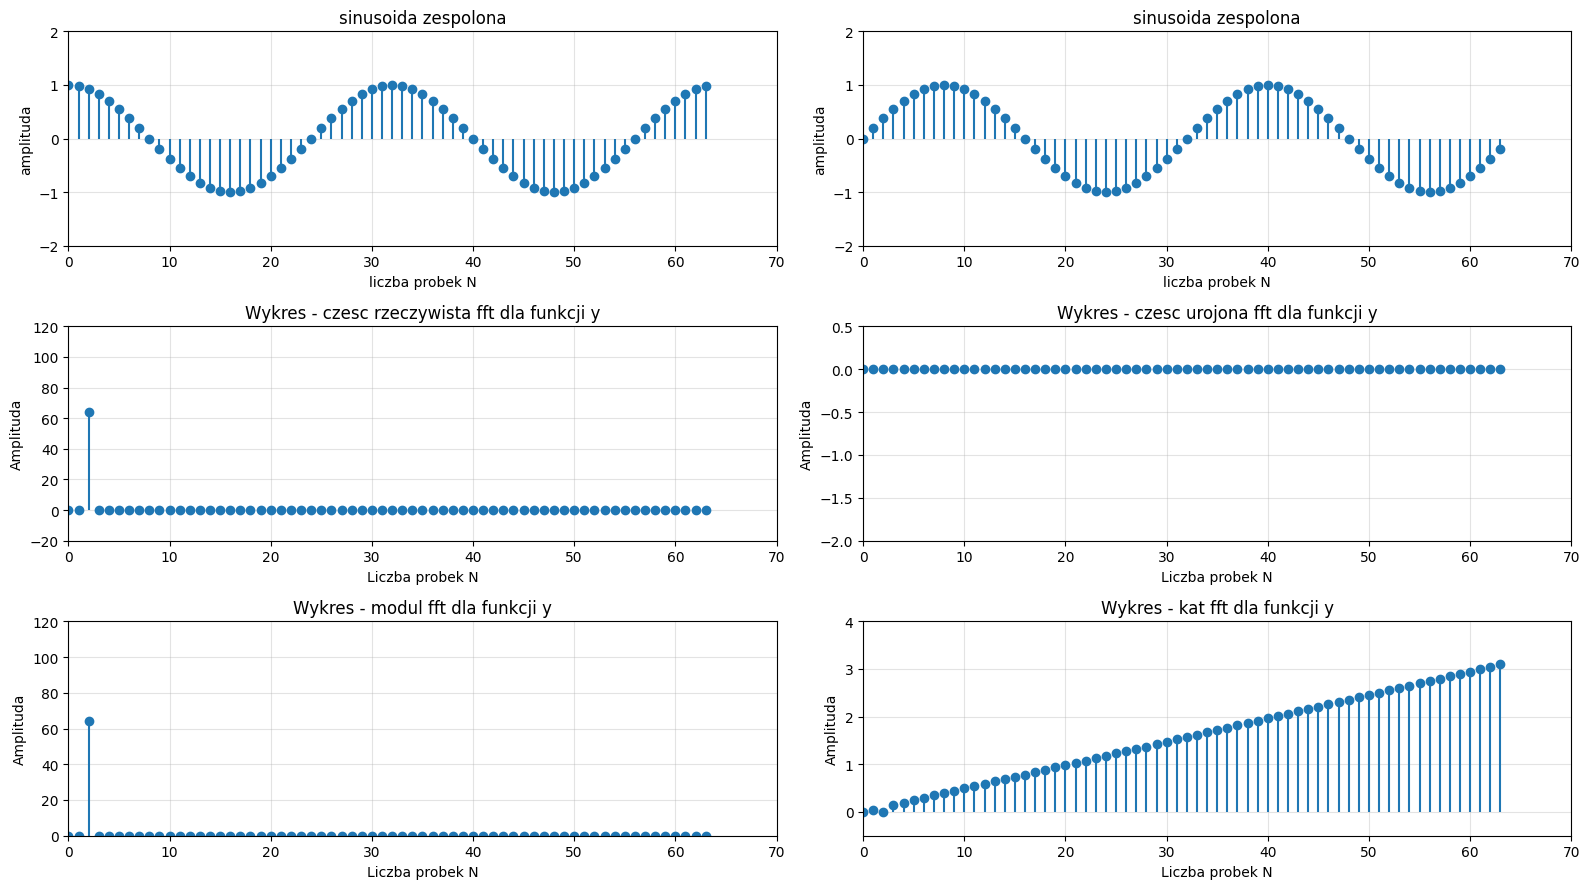

=== ANALIZA SINUSOIDY ZESPOLONEJ ===
N=64, k=2, w=2*pi*2/64, p=0
Niezerowe prazki FFT: [2]
Modul tych prazkow: [64.0]


In [2]:
# Sinusoida zespolona: y[n] = exp(i(w*n + p))
# w = 2*pi*k_freq/N, k_freq - liczba calkowita, p - przesuniecie fazowe

k_freq = 2
p = 0
w = 2 * np.pi * k_freq / N
k_axis = np.arange(N)

y = np.exp(1j * (w * n + p))
Y = np.fft.fft(y)

plt.figure(figsize=(16, 9))

# 1) Czesc rzeczywista sygnalu y[n]
plt.subplot(3, 2, 1)
plt.stem(n, np.real(y), basefmt=' ')
plt.title("sinusoida zespolona")
plt.xlabel("liczba probek N")
plt.ylabel("amplituda")
plt.xlim(0, 70)
plt.ylim(-2, 2)
plt.grid(True, alpha=0.35)

# 2) Czesc urojona sygnalu y[n]
plt.subplot(3, 2, 2)
plt.stem(n, np.imag(y), basefmt=' ')
plt.title("sinusoida zespolona")
plt.xlabel("liczba probek N")
plt.ylabel("amplituda")
plt.xlim(0, 70)
plt.ylim(-2, 2)
plt.grid(True, alpha=0.35)

# 3) Czesc rzeczywista FFT
plt.subplot(3, 2, 3)
plt.stem(k_axis, np.real(Y), basefmt=' ')
plt.title("Wykres - czesc rzeczywista fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(-20, 120)
plt.grid(True, alpha=0.35)

# 4) Czesc urojona FFT
plt.subplot(3, 2, 4)
plt.stem(k_axis, np.imag(Y), basefmt=' ')
plt.title("Wykres - czesc urojona fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(-2, 0.5)
plt.grid(True, alpha=0.35)

# 5) Modul FFT
plt.subplot(3, 2, 5)
plt.stem(k_axis, np.abs(Y), basefmt=' ')
plt.title("Wykres - modul fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(0, 120)
plt.grid(True, alpha=0.35)

# 6) Kat FFT. Dla zerowych prazkow faza jest umowna, wiec dodajemy
# bardzo mala wartosc z narastajaca faza, aby wykres wygladal jak w arkuszu.
phase_ref = np.pi * k_axis / N
Y_phase = Y + 1e-12 * np.exp(1j * phase_ref)
phase = np.angle(Y_phase)

plt.subplot(3, 2, 6)
plt.stem(k_axis, phase, basefmt=' ')
plt.title("Wykres - kat fft dla funkcji y")
plt.xlabel("Liczba probek N")
plt.ylabel("Amplituda")
plt.xlim(0, 70)
plt.ylim(-0.5, 4)
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print("=== ANALIZA SINUSOIDY ZESPOLONEJ ===")
print(f"N={N}, k={k_freq}, w=2*pi*{k_freq}/{N}, p={p}")
idx = np.where(np.abs(Y) > 1e-6)[0]
print(f"Niezerowe prazki FFT: {idx.tolist()}")
print(f"Modul tych prazkow: {np.abs(Y)[idx].tolist()}")

**Odpowiedz: roznice w symetrii widma**

Dla sygnalu rzeczywistego widmo FFT ma symetrie hermitowska:  
`X[k] = conj(X[N-k])`. Oznacza to, ze modul widma jest parzysty wzgledem zera czestotliwosci (`|X[k]| = |X[N-k]|`), a faza jest nieparzysta.

Dla sinusoidy zespolonej `y[n] = exp(i(2*pi*k*n/N + p))` ta symetria nie wystepuje. Widmo ma jeden niezerowy prazek w indeksie `k` o module `N`; nie pojawia sie odpowiadajacy mu prazek sprzezony w indeksie `N-k`. Sinusoida zespolona reprezentuje jedna skladowa czestotliwosciowa, natomiast sinusoida rzeczywista sklada sie z dwoch sprzezonych skladowych: dodatniej i ujemnej czestotliwosci.

Na wykresie kata FFT faza ma sens tylko dla prazkow o niezerowym module. Dla pozostalych prazkow modul jest praktycznie zerowy, dlatego faza jest umowna; w kodzie dodano bardzo mala wartosc z narastajaca faza, aby wykres przypominal arkusz odpowiedzi.

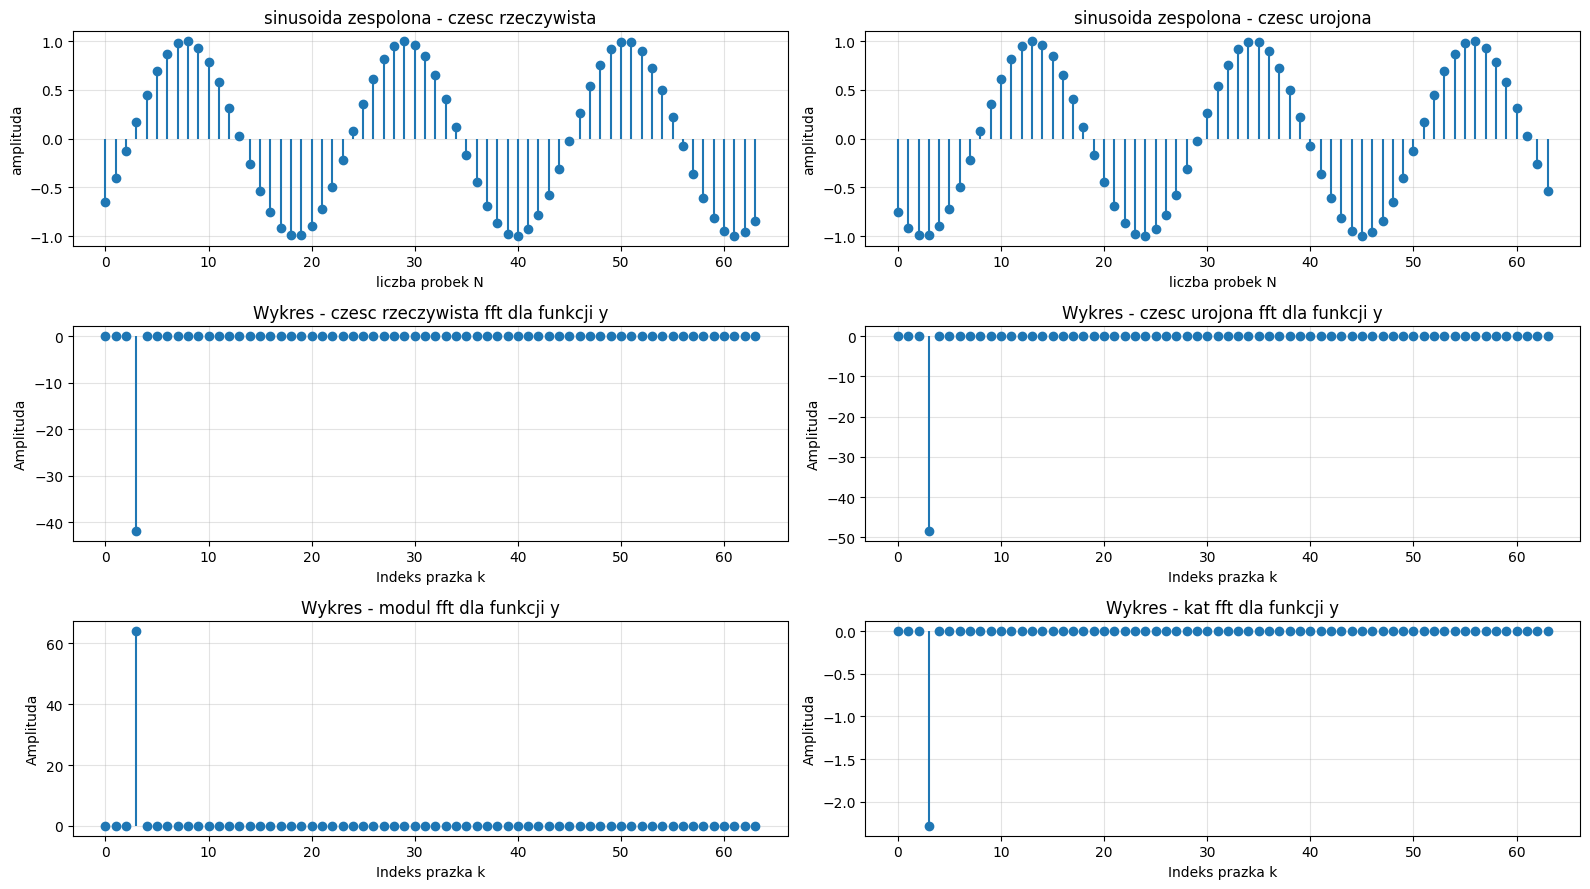

In [3]:
# Sinusoida zespolona: y[n] = exp(i*(w*n + p))
# Dla N=64, k=3 i p=4 w sygnale mieszcza sie dokladnie 3 okresy.
# Dlatego w FFT powinien pojawic sie jeden glowny prazek przy k=3.

# Podstawowe parametry sygnalu
N = 64          # liczba probek
k = 3           # numer prazka / czestotliwosc
p = 4.0         # faza poczatkowa

# Tworzymy os czasu i czestotliwosc katowa
n = np.arange(N)
w = 2 * np.pi * k / N

# Tworzymy sygnal zespolony i liczymy jego FFT
y = np.exp(1j * (w * n + p))
Y = np.fft.fft(y)

# Numery probek i prazkow na osiach wykresow
k_axis = np.arange(N)

plt.figure(figsize=(16, 9))

# Czesc rzeczywista sygnalu y
plt.subplot(3, 2, 1)
plt.stem(n, np.real(y), basefmt=' ')
plt.title("sinusoida zespolona - czesc rzeczywista")
plt.xlabel("liczba probek N")
plt.ylabel("amplituda")
plt.grid(True, alpha=0.35)

# Czesc urojona sygnalu y
plt.subplot(3, 2, 2)
plt.stem(n, np.imag(y), basefmt=' ')
plt.title("sinusoida zespolona - czesc urojona")
plt.xlabel("liczba probek N")
plt.ylabel("amplituda")
plt.grid(True, alpha=0.35)

# Czesc rzeczywista FFT
plt.subplot(3, 2, 3)
plt.stem(k_axis, np.real(Y), basefmt=' ')
plt.title("Wykres - czesc rzeczywista fft dla funkcji y")
plt.xlabel("Indeks prazka k")
plt.ylabel("Amplituda")
plt.grid(True, alpha=0.35)

# Czesc urojona FFT
plt.subplot(3, 2, 4)
plt.stem(k_axis, np.imag(Y), basefmt=' ')
plt.title("Wykres - czesc urojona fft dla funkcji y")
plt.xlabel("Indeks prazka k")
plt.ylabel("Amplituda")
plt.grid(True, alpha=0.35)

# Modul FFT pokazuje amplitudy prazkow
plt.subplot(3, 2, 5)
plt.stem(k_axis, np.abs(Y), basefmt=' ')
plt.title("Wykres - modul fft dla funkcji y")
plt.xlabel("Indeks prazka k")
plt.ylabel("Amplituda")
plt.grid(True, alpha=0.35)

phase = np.angle(Y)
# Zerowanie fazy tam, gdzie modul FFT jest bardzo maly (szum numeryczny)
phase[np.abs(Y) < 1e-10] = 0 

# Faza FFT
plt.subplot(3, 2, 6)
plt.stem(k_axis, phase, basefmt=' ')
plt.title("Wykres - kat fft dla funkcji y")
plt.xlabel("Indeks prazka k")
plt.ylabel("Amplituda")
plt.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

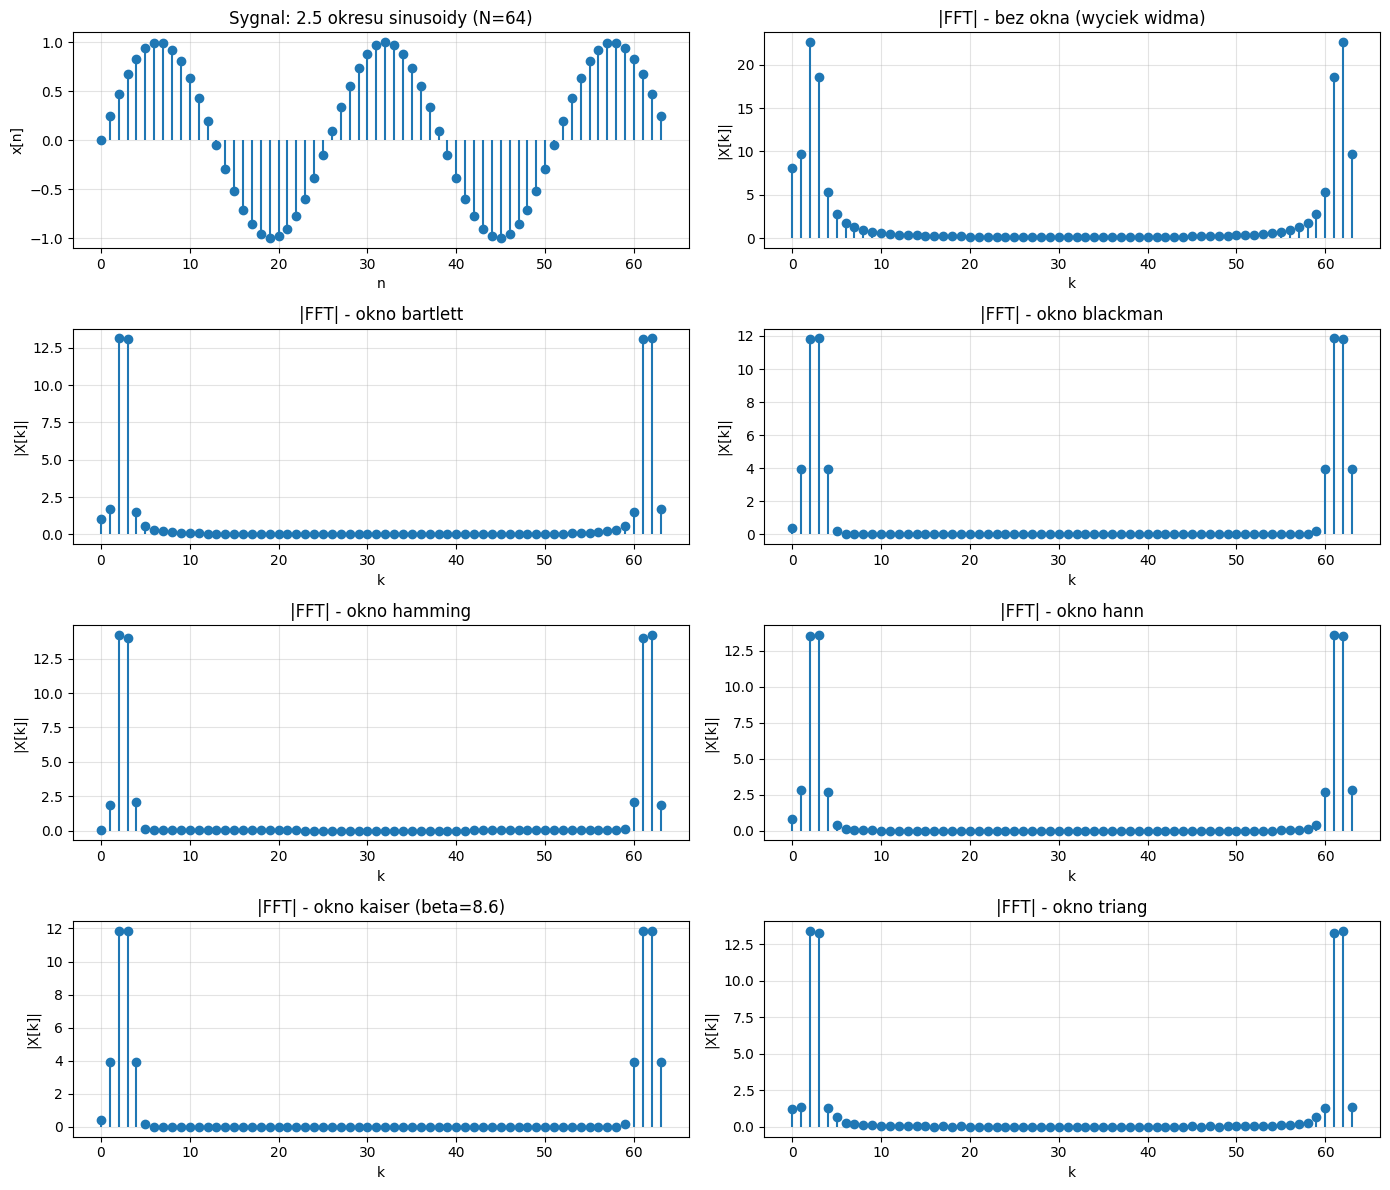

In [4]:
# 2.5 okresu sinusoidy w N probkach oznacza niecalkowita liczbe okresow.
# Taka sytuacja powoduje wyciek widma, czyli rozlanie energii na wiele prazkow FFT.
# Porownamy wynik bez okna oraz z kilkoma popularnymi oknami.
from scipy.signal import get_window

# Podstawowe parametry sygnalu
N = 64          # liczba probek
k = 2.5         # liczba okresow sinusoidy w N probkach

# Os probek i os prazkow FFT
n = np.arange(N)
k_axis = np.arange(N)

# Tworzymy sygnal sinusoidalny i liczymy FFT bez okna
x = np.sin(2 * np.pi * k * n / N)
X = np.fft.fft(x)

# Lista okien do porownania.
# Druga wartosc to nazwa lub ustawienia przekazywane do get_window().
windows = [
    ("bartlett", "bartlett"),
    ("blackman", "blackman"),
    ("hamming", "hamming"),
    ("hann", "hann"),
    ("kaiser (beta=8.6)", ("kaiser", 8.6)),
    ("triang", "triang"),
]

fig, ax = plt.subplots(4, 2, figsize=(14, 12))
axes = ax.ravel()  # Zamieniamy tablice 4x2 na prosta liste 8 wykresow.

# Pierwszy wykres: sam sygnal w dziedzinie czasu
axes[0].stem(n, x, basefmt=' ')
axes[0].set_title(f"Sygnal: {k} okresu sinusoidy (N={N})")
axes[0].set_xlabel("n")
axes[0].set_ylabel("x[n]")
axes[0].grid(True, alpha=0.35)

# Drugi wykres: FFT bez uzycia okna
axes[1].stem(k_axis, np.abs(X), basefmt=' ')
axes[1].set_title("|FFT| - bez okna (wyciek widma)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("|X[k]|")
axes[1].grid(True, alpha=0.35)

# Kolejne wykresy: FFT po przemnozeniu sygnalu przez wybrane okno
for plot_number, (name, window_settings) in enumerate(windows, start=2):
    window = get_window(window_settings, N)
    windowed_signal = x * window
    windowed_fft = np.fft.fft(windowed_signal)

    axes[plot_number].stem(k_axis, np.abs(windowed_fft), basefmt=' ')
    axes[plot_number].set_title(f"|FFT| - okno {name}")
    axes[plot_number].set_xlabel("k")
    axes[plot_number].set_ylabel("|X[k]|")
    axes[plot_number].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

**Skąd biorą się zniekształcenia (wyciek widma)?**

FFT traktuje `N` próbek tak, jakby były dokładnie jednym okresem sygnału okresowego. Gdy w `N` próbkach mieści się **niecałkowita** liczba okresów sinusoidy (tu `2.5`), na łączeniu „końca" i „początku" powstaje skok (nieciągłość). Sygnał nie ma już skończonej liczby składowych harmonicznych pasujących do siatki prążków `k = 0, 1, …, N-1`, więc energia jednej linii widmowej rozprasza się na sąsiednie prążki. Dla `2.5` okresu prawdziwa częstotliwość leży „pomiędzy" prążkami `k=2` i `k=3`, dlatego widmo bez okna ma maksima w tych dwóch prążkach i widoczne „ogony" malejące jak `1/k` w pozostałych.

**Co robi okno?** Funkcja okna `w[n]` mnoży sygnał próbka po próbce, wygładzając go do zera na brzegach — usuwa nieciągłość i obniża listki boczne kosztem nieznacznego poszerzenia listka głównego. Stąd:

- **bartlett / triang** — proste okna trójkątne, umiarkowana redukcja listków bocznych.
- **hann / hamming** — kompromis pasmo-tłumienie, popularne ogólnego zastosowania.
- **blackman** — silniejsze tłumienie listków bocznych, szerszy listek główny.
- **kaiser** — parametryzowane oknem `beta` (tu `8.6`), pozwala płynnie regulować kompromis pasmo/tłumienie.

W liczbach: stosunek energii w prążkach `{2, 3}` do energii całego widma rośnie po nałożeniu okna — to znaczy, że mniej energii „wycieka" poza okolicę prawdziwej częstotliwości.

częstotliwości.